In [1]:
suppressPackageStartupMessages({
    library(ggplot2)
    library(Seurat)
    library(dplyr)
    library(tidyr)
    library(tibble)
    library(stringr)
    library(dittoSeq)
    library(patchwork)
    library(future)
    plan("multicore", workers = 12)
    options(future.globals.maxSize = 1000 * 1024^5)
    options(stringsAsFactors = FALSE)
    set.seed(123)
})

Warning message:
“package ‘ggplot2’ was built under R version 4.3.3”


In [3]:
path_ref <- '/projects/0/einf2548/cruiz/dmg/data/rna_dmg_atlas_scglue_embbeding.rds'
dmg <- readRDS(path_ref)
dmg

An object of class Seurat 
19248 features across 397794 samples within 1 assay 
Active assay: RNA (19248 features, 2000 variable features)
 3 layers present: counts, data, scale.data
 2 dimensional reductions calculated: pca, umap

In [ ]:
dmg <-  subset(dmg, lvl_2 %in% c('Stem_like',
                                  'Differentiated_like',
                                  'Myeloid'))

`summarise()` has grouped output by 'SampleID', 'lvl_1'. You can override using the `.groups` argument.


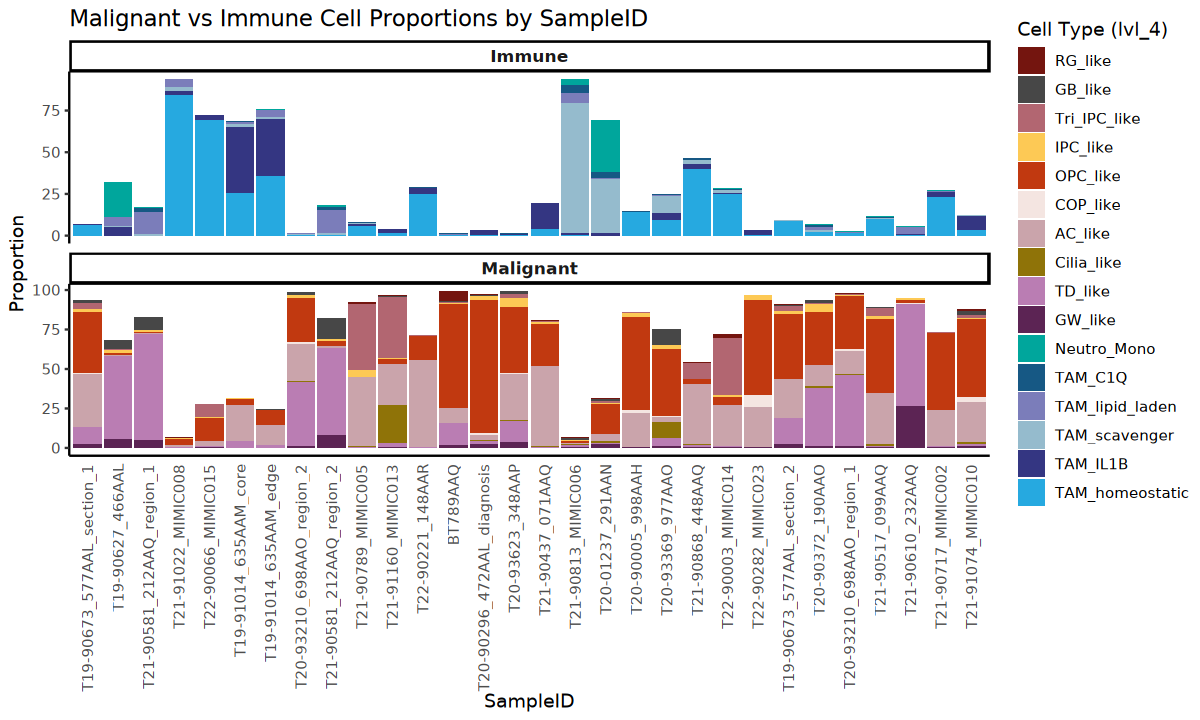

In [34]:
# Step 1: Fetch the metadata from Seurat object `dmg`, including SampleID
meta_data <- FetchData(subset(dmg, Clinical_status=='Primary'), vars = c('lvl_1', 'lvl_4', 'SampleID'))

# Step 2: Calculate total counts of cells (Malignant + Immune) per SampleID
total_counts <- meta_data %>%
  group_by(SampleID) %>%
  summarise(total_cells = n()) %>%
  ungroup()

# Step 3: Calculate the proportion of Malignant and Immune cells within each SampleID
meta_data_with_total <- meta_data %>%
  group_by(SampleID, lvl_1, lvl_4) %>%
  summarise(count = n()) %>%
  ungroup()

# Step 4: Calculate the total number of Malignant and Immune cells within each SampleID
# Normalize the total between Malignant and Immune to 100%
meta_data_with_total <- meta_data_with_total %>%
  group_by(SampleID) %>%
  mutate(total_by_type = sum(count)) %>%
  ungroup() %>%
  mutate(percentage = (count / total_by_type) * 100)

# Step 5: Split into two groups (Malignant and Immune)
malignant_data <- meta_data_with_total %>%
  filter(lvl_1 == "Malignant")

immune_data <- meta_data_with_total %>%
  filter(lvl_1 == "Immune")

# Step 6: Add 'Type' column to differentiate Malignant from Immune
malignant_data <- malignant_data %>%
  mutate(Type = "Malignant")

immune_data <- immune_data %>%
  mutate(Type = "Immune")

# Combine malignant and immune data
combined_data <- bind_rows(malignant_data, immune_data)

# Reorder the data based on cell type proportions in each SampleID
combined_data <- combined_data %>%
  group_by(SampleID) %>%
  mutate(rank = rank(-percentage)) %>%
  ungroup() %>%
  mutate(SampleID = reorder(SampleID, rank))

# Step 8: Create the Stacked Bar Plot
options(repr.plot.height = 6, repr.plot.width = 10)

ggplot(combined_data, aes(x = SampleID, y = percentage, fill = lvl_4)) +
  geom_bar(stat = "identity") +
  scale_fill_manual(values = colors) +
  facet_wrap(~ Type, scales = "free_y", nrow = 2, strip.position = "top") +
  theme_classic() +
  theme(
    strip.text.x = element_text(size = 10, face = "bold"),
    axis.text.x = element_text(angle = 90, hjust = 1, vjust = 0.5),
    axis.ticks.x = element_blank(),
    panel.spacing.x = unit(1, "lines")  # Adjust to control space between groups
  ) +
  labs(x = "SampleID", y = "Proportion", fill = "Cell Type (lvl_4)", 
       title = "Malignant vs Immune Cell Proportions by SampleID")

`summarise()` has grouped output by 'SampleID'. You can override using the `.groups` argument.
`summarise()` has grouped output by 'SampleID'. You can override using the `.groups` argument.


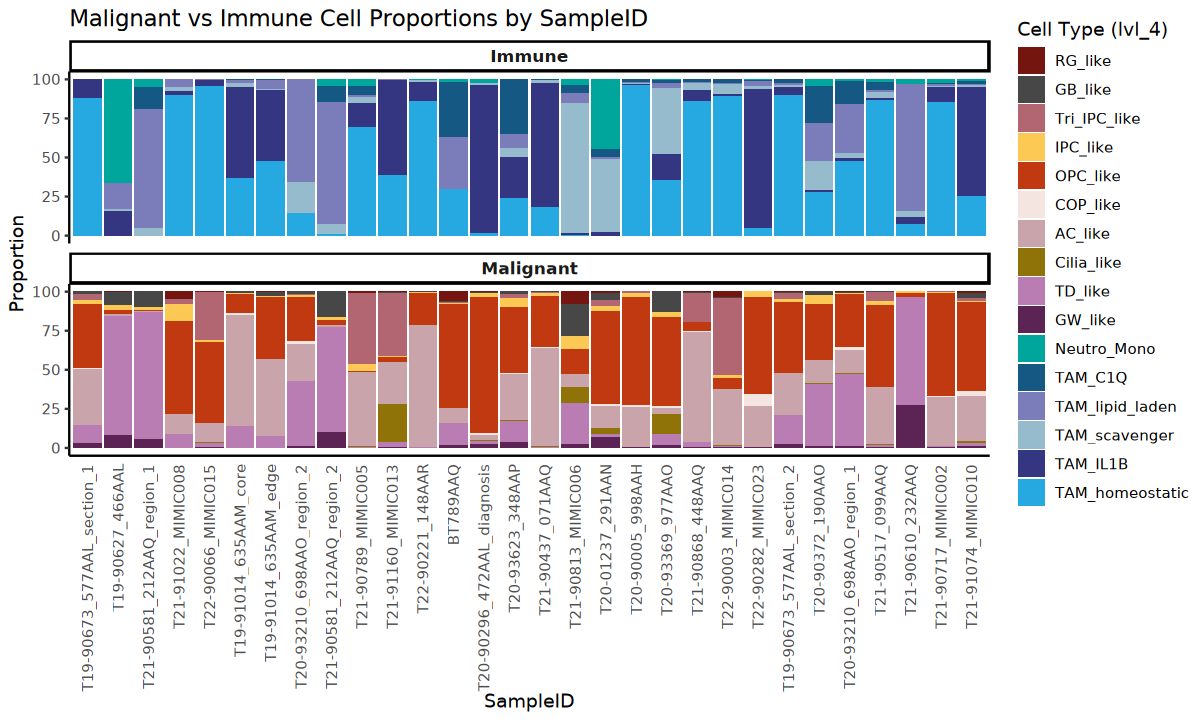

In [35]:
# Step 1: Fetch the metadata from Seurat object `dmg`, including SampleID
meta_data <- FetchData(subset(dmg, Clinical_status=='Primary'), vars = c('lvl_1', 'lvl_4', 'SampleID'))

# Step 2: Separate Malignant and Immune Cells
malignant_data <- meta_data %>%
  filter(lvl_1 == "Malignant")

immune_data <- meta_data %>%
  filter(lvl_1 == "Immune")

# Step 3: Calculate Proportions for Malignant and Immune for each SampleID
malignant_prop <- malignant_data %>%
  group_by(SampleID, lvl_4) %>%
  summarise(count = n()) %>%
  mutate(percentage = (count / sum(count)) * 100)

immune_prop <- immune_data %>%
  group_by(SampleID, lvl_4) %>%
  summarise(count = n()) %>%
  mutate(percentage = (count / sum(count)) * 100)

# Step 4: Add 'Type' column to differentiate Malignant from Immune
malignant_prop <- malignant_prop %>%
  mutate(Type = "Malignant")

immune_prop <- immune_prop %>%
  mutate(Type = "Immune")

# Combine malignant and immune proportions
combined_prop <- bind_rows(malignant_prop, immune_prop)

# Step 5: Prepare for Plotting

# Reorder the data based on cell type proportions in each SampleID
combined_prop <- combined_prop %>%
  group_by(SampleID) %>%
  mutate(rank = rank(-percentage)) %>%
  ungroup() %>%
  mutate(SampleID = reorder(SampleID, rank))

# Step 6: Create the Stacked Bar Plot
options(repr.plot.height = 6, repr.plot.width = 10)

ggplot(combined_prop, aes(x = SampleID, y = percentage, fill = lvl_4)) +
  geom_bar(stat = "identity") +
  scale_fill_manual(values = colors) +
  facet_wrap(~ Type, scales = "free_y", nrow = 2, strip.position = "top") +
  theme_classic() +
  theme(
    strip.text.x = element_text(size = 10, face = "bold"),
    axis.text.x = element_text(angle = 90, hjust = 1, vjust = 0.5),
    axis.ticks.x = element_blank(),
    panel.spacing.x = unit(1, "lines")  # Adjust this to control space between groups
  ) +
  labs(x = "SampleID", y = "Proportion", fill = "Cell Type (lvl_4)", 
       title = "Malignant vs Immune Cell Proportions by SampleID")

`summarise()` has grouped output by 'SampleID', 'lvl_1'. You can override using the `.groups` argument.
`summarise()` has grouped output by 'SampleID'. You can override using the `.groups` argument.


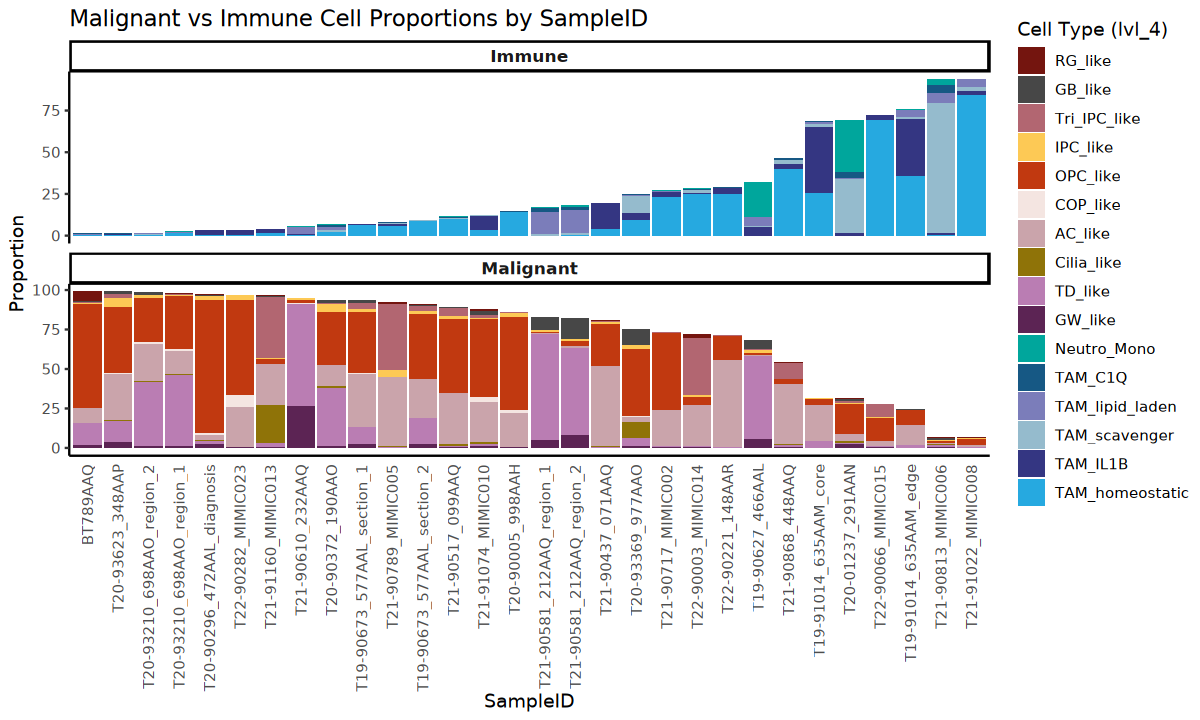

In [49]:
library(Seurat)
library(dplyr)
library(ggplot2)

# Step 1: Fetch the metadata from Seurat object `dmg`, including SampleID
meta_data <- FetchData(subset(dmg, Clinical_status=='Primary'), vars = c('lvl_1', 'lvl_4', 'SampleID'))

# Step 2: Calculate total counts of cells (Malignant + Immune) per SampleID
total_counts <- meta_data %>%
  group_by(SampleID) %>%
  summarise(total_cells = n()) %>%
  ungroup()

# Step 3: Calculate the proportion of Malignant and Immune cells within each SampleID
meta_data_with_total <- meta_data %>%
  group_by(SampleID, lvl_1, lvl_4) %>%
  summarise(count = n()) %>%
  ungroup()

# Step 4: Calculate the total number of Malignant and Immune cells within each SampleID
# Normalize the total between Malignant and Immune to 100%
meta_data_with_total <- meta_data_with_total %>%
  group_by(SampleID) %>%
  mutate(total_by_type = sum(count)) %>%
  ungroup() %>%
  mutate(percentage = (count / total_by_type) * 100)

# Step 5: Split into two groups (Malignant and Immune)
malignant_data <- meta_data_with_total %>%
  filter(lvl_1 == "Malignant")

immune_data <- meta_data_with_total %>%
  filter(lvl_1 == "Immune")

# Step 6: Add 'Type' column to differentiate Malignant from Immune
malignant_data <- malignant_data %>%
  mutate(Type = "Malignant")

immune_data <- immune_data %>%
  mutate(Type = "Immune")

# Combine malignant and immune data
combined_data <- bind_rows(malignant_data, immune_data)

# Step 7: Calculate overall proportions for Malignant and Immune by SampleID
overall_proportion <- combined_data %>%
  group_by(SampleID, Type) %>%
  summarise(total_percentage = sum(percentage)) %>%
  pivot_wider(names_from = Type, values_from = total_percentage) %>%
  arrange(desc(Malignant), Immune)

# Reorder SampleID by overall abundance of Malignant (descending) and Immune (ascending)
combined_data <- combined_data %>%
  mutate(SampleID = factor(SampleID, levels = overall_proportion$SampleID))

# Step 8: Create the Stacked Bar Plot
options(repr.plot.height = 6, repr.plot.width = 10)

ggplot(combined_data, aes(x = SampleID, y = percentage, fill = lvl_4)) +
  geom_bar(stat = "identity") +
  scale_fill_manual(values = colors) +
  facet_wrap(~ Type, scales = "free_y", nrow = 2, strip.position = "top") +
  theme_classic() +
  theme(
    strip.text.x = element_text(size = 10, face = "bold"),
    axis.text.x = element_text(angle = 90, hjust = 1, vjust = 0.5),
    axis.ticks.x = element_blank(),
    panel.spacing.x = unit(1, "lines")  # Adjust to control space between groups
  ) +
  labs(x = "SampleID", y = "Proportion", fill = "Cell Type (lvl_4)", 
       title = "Malignant vs Immune Cell Proportions by SampleID")

In [50]:
ggsave('figures/barplot_primary_malignant_myeloid.pdf', height = 6, width = 9)

### Recurrence

`summarise()` has grouped output by 'SampleID', 'lvl_1'. You can override using the `.groups` argument.


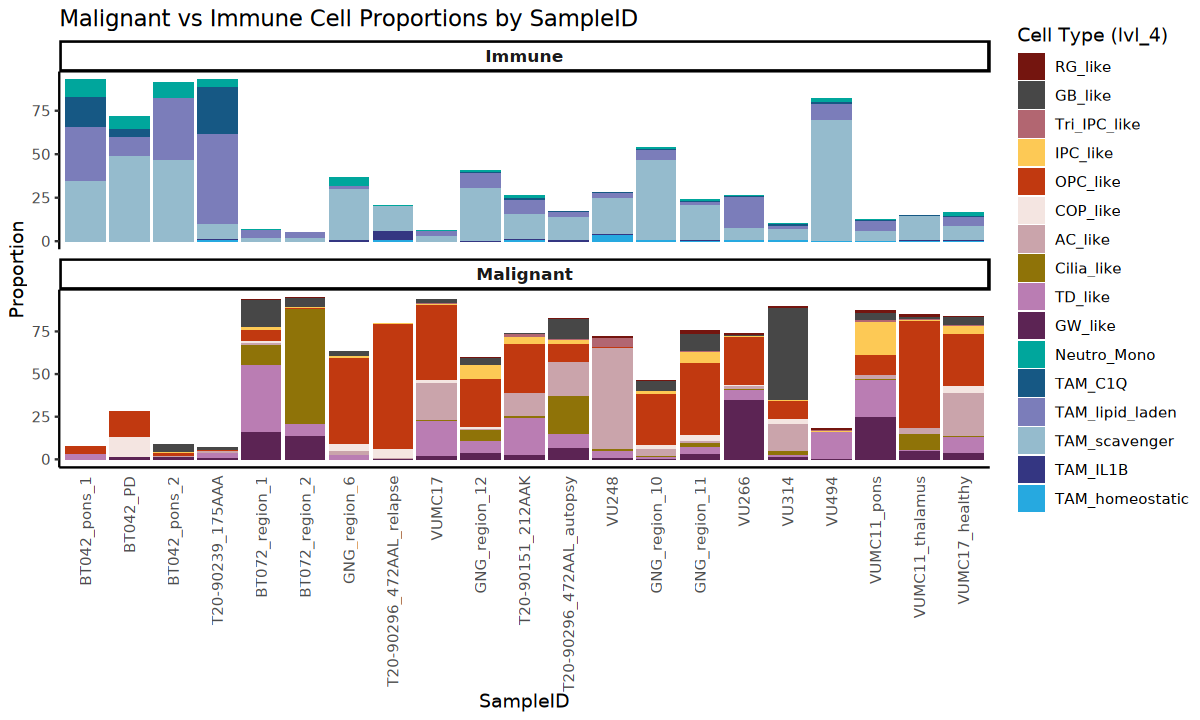

In [44]:
# Step 1: Fetch the metadata from Seurat object `dmg`, including SampleID
meta_data <- FetchData(subset(dmg, Clinical_status=='Recurrence'), vars = c('lvl_1', 'lvl_4', 'SampleID'))

# Step 2: Calculate total counts of cells (Malignant + Immune) per SampleID
total_counts <- meta_data %>%
  group_by(SampleID) %>%
  summarise(total_cells = n()) %>%
  ungroup()

# Step 3: Calculate the proportion of Malignant and Immune cells within each SampleID
meta_data_with_total <- meta_data %>%
  group_by(SampleID, lvl_1, lvl_4) %>%
  summarise(count = n()) %>%
  ungroup()

# Step 4: Calculate the total number of Malignant and Immune cells within each SampleID
# Normalize the total between Malignant and Immune to 100%
meta_data_with_total <- meta_data_with_total %>%
  group_by(SampleID) %>%
  mutate(total_by_type = sum(count)) %>%
  ungroup() %>%
  mutate(percentage = (count / total_by_type) * 100)

# Step 5: Split into two groups (Malignant and Immune)
malignant_data <- meta_data_with_total %>%
  filter(lvl_1 == "Malignant")

immune_data <- meta_data_with_total %>%
  filter(lvl_1 == "Immune")

# Step 6: Add 'Type' column to differentiate Malignant from Immune
malignant_data <- malignant_data %>%
  mutate(Type = "Malignant")

immune_data <- immune_data %>%
  mutate(Type = "Immune")

# Combine malignant and immune data
combined_data <- bind_rows(malignant_data, immune_data)

# Reorder the data based on cell type proportions in each SampleID
combined_data <- combined_data %>%
  group_by(SampleID) %>%
  mutate(rank = rank(-percentage)) %>%
  ungroup() %>%
  mutate(SampleID = reorder(SampleID, rank))

# Step 8: Create the Stacked Bar Plot
options(repr.plot.height = 6, repr.plot.width = 10)

ggplot(combined_data, aes(x = SampleID, y = percentage, fill = lvl_4)) +
  geom_bar(stat = "identity") +
  scale_fill_manual(values = colors) +
  facet_wrap(~ Type, scales = "free_y", nrow = 2, strip.position = "top") +
  theme_classic() +
  theme(
    strip.text.x = element_text(size = 10, face = "bold"),
    axis.text.x = element_text(angle = 90, hjust = 1, vjust = 0.5),
    axis.ticks.x = element_blank(),
    panel.spacing.x = unit(1, "lines")  # Adjust to control space between groups
  ) +
  labs(x = "SampleID", y = "Proportion", fill = "Cell Type (lvl_4)", 
       title = "Malignant vs Immune Cell Proportions by SampleID")

`summarise()` has grouped output by 'SampleID'. You can override using the `.groups` argument.
`summarise()` has grouped output by 'SampleID'. You can override using the `.groups` argument.


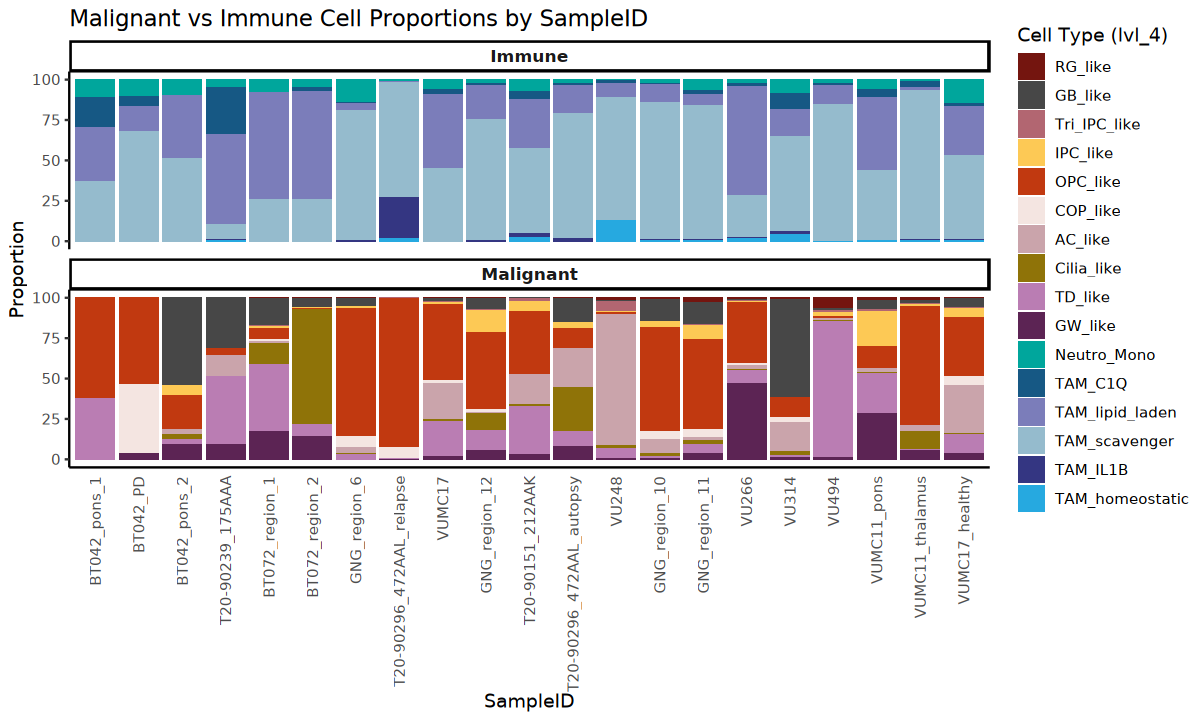

In [45]:
# Step 1: Fetch the metadata from Seurat object `dmg`, including SampleID
meta_data <- FetchData(subset(dmg, Clinical_status=='Recurrence'), vars = c('lvl_1', 'lvl_4', 'SampleID'))

# Step 2: Separate Malignant and Immune Cells
malignant_data <- meta_data %>%
  filter(lvl_1 == "Malignant")

immune_data <- meta_data %>%
  filter(lvl_1 == "Immune")

# Step 3: Calculate Proportions for Malignant and Immune for each SampleID
malignant_prop <- malignant_data %>%
  group_by(SampleID, lvl_4) %>%
  summarise(count = n()) %>%
  mutate(percentage = (count / sum(count)) * 100)

immune_prop <- immune_data %>%
  group_by(SampleID, lvl_4) %>%
  summarise(count = n()) %>%
  mutate(percentage = (count / sum(count)) * 100)

# Step 4: Add 'Type' column to differentiate Malignant from Immune
malignant_prop <- malignant_prop %>%
  mutate(Type = "Malignant")

immune_prop <- immune_prop %>%
  mutate(Type = "Immune")

# Combine malignant and immune proportions
combined_prop <- bind_rows(malignant_prop, immune_prop)

# Step 5: Prepare for Plotting

# Reorder the data based on cell type proportions in each SampleID
combined_prop <- combined_prop %>%
  group_by(SampleID) %>%
  mutate(rank = rank(-percentage)) %>%
  ungroup() %>%
  mutate(SampleID = reorder(SampleID, rank))

# Step 6: Create the Stacked Bar Plot
options(repr.plot.height = 6, repr.plot.width = 10)

ggplot(combined_prop, aes(x = SampleID, y = percentage, fill = lvl_4)) +
  geom_bar(stat = "identity") +
  scale_fill_manual(values = colors) +
  facet_wrap(~ Type, scales = "free_y", nrow = 2, strip.position = "top") +
  theme_classic() +
  theme(
    strip.text.x = element_text(size = 10, face = "bold"),
    axis.text.x = element_text(angle = 90, hjust = 1, vjust = 0.5),
    axis.ticks.x = element_blank(),
    panel.spacing.x = unit(1, "lines")  # Adjust this to control space between groups
  ) +
  labs(x = "SampleID", y = "Proportion", fill = "Cell Type (lvl_4)", 
       title = "Malignant vs Immune Cell Proportions by SampleID")

`summarise()` has grouped output by 'SampleID', 'lvl_1'. You can override using the `.groups` argument.
`summarise()` has grouped output by 'SampleID'. You can override using the `.groups` argument.


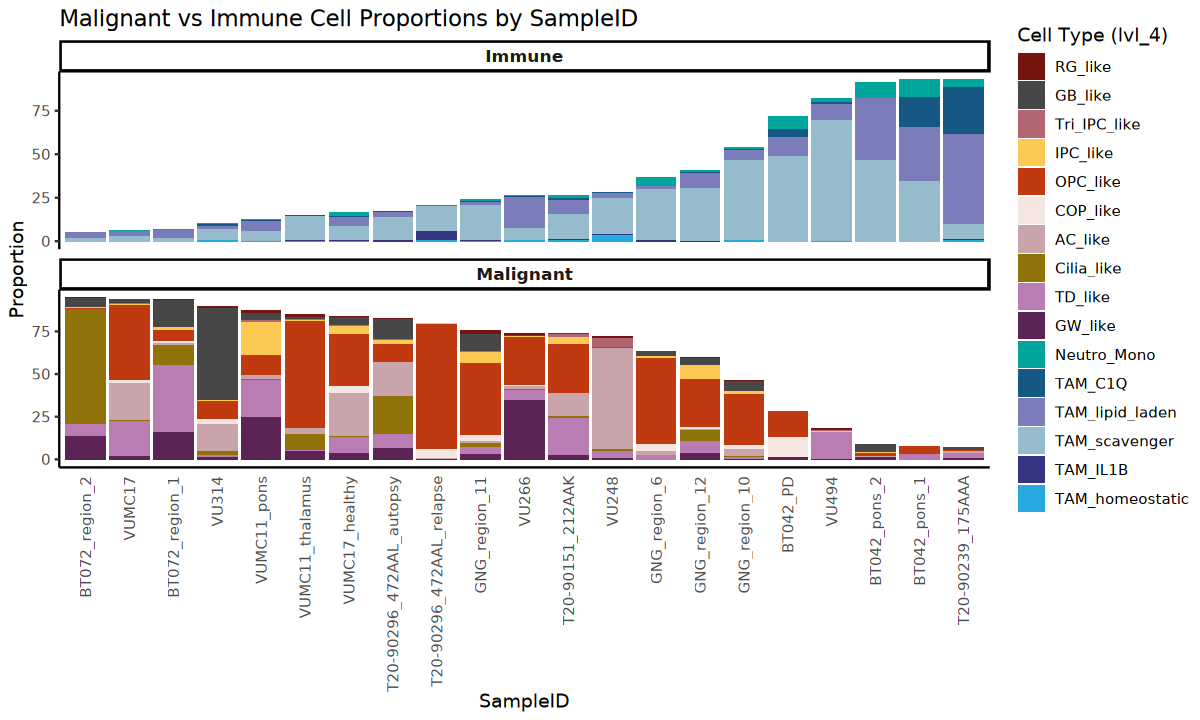

In [51]:
library(Seurat)
library(dplyr)
library(ggplot2)

# Step 1: Fetch the metadata from Seurat object `dmg`, including SampleID
meta_data <- FetchData(subset(dmg, Clinical_status=='Recurrence'), vars = c('lvl_1', 'lvl_4', 'SampleID'))

# Step 2: Calculate total counts of cells (Malignant + Immune) per SampleID
total_counts <- meta_data %>%
  group_by(SampleID) %>%
  summarise(total_cells = n()) %>%
  ungroup()

# Step 3: Calculate the proportion of Malignant and Immune cells within each SampleID
meta_data_with_total <- meta_data %>%
  group_by(SampleID, lvl_1, lvl_4) %>%
  summarise(count = n()) %>%
  ungroup()

# Step 4: Calculate the total number of Malignant and Immune cells within each SampleID
# Normalize the total between Malignant and Immune to 100%
meta_data_with_total <- meta_data_with_total %>%
  group_by(SampleID) %>%
  mutate(total_by_type = sum(count)) %>%
  ungroup() %>%
  mutate(percentage = (count / total_by_type) * 100)

# Step 5: Split into two groups (Malignant and Immune)
malignant_data <- meta_data_with_total %>%
  filter(lvl_1 == "Malignant")

immune_data <- meta_data_with_total %>%
  filter(lvl_1 == "Immune")

# Step 6: Add 'Type' column to differentiate Malignant from Immune
malignant_data <- malignant_data %>%
  mutate(Type = "Malignant")

immune_data <- immune_data %>%
  mutate(Type = "Immune")

# Combine malignant and immune data
combined_data <- bind_rows(malignant_data, immune_data)

# Step 7: Calculate overall proportions for Malignant and Immune by SampleID
overall_proportion <- combined_data %>%
  group_by(SampleID, Type) %>%
  summarise(total_percentage = sum(percentage)) %>%
  pivot_wider(names_from = Type, values_from = total_percentage) %>%
  arrange(desc(Malignant), Immune)

# Reorder SampleID by overall abundance of Malignant (descending) and Immune (ascending)
combined_data <- combined_data %>%
  mutate(SampleID = factor(SampleID, levels = overall_proportion$SampleID))

# Step 8: Create the Stacked Bar Plot
options(repr.plot.height = 6, repr.plot.width = 10)

ggplot(combined_data, aes(x = SampleID, y = percentage, fill = lvl_4)) +
  geom_bar(stat = "identity") +
  scale_fill_manual(values = colors) +
  facet_wrap(~ Type, scales = "free_y", nrow = 2, strip.position = "top") +
  theme_classic() +
  theme(
    strip.text.x = element_text(size = 10, face = "bold"),
    axis.text.x = element_text(angle = 90, hjust = 1, vjust = 0.5),
    axis.ticks.x = element_blank(),
    panel.spacing.x = unit(1, "lines")  # Adjust to control space between groups
  ) +
  labs(x = "SampleID", y = "Proportion", fill = "Cell Type (lvl_4)", 
       title = "Malignant vs Immune Cell Proportions by SampleID")

In [53]:
ggsave('figures/barplot_recurrence_malignant_myeloid.pdf', height = 6, width = 6)